In [ ]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [3]:
# load the California housing dataset
data = fetch_california_housing()

X = data.data
y = data.target

feature_names = data.feature_names

df = pd.DataFrame(X, columns=feature_names)
df["Target"] = y

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# xem dữ liệu
print("Shape của X:", X.shape)
print("Shape của y:", y.shape)

df.info()
df.describe()

Shape của X: (20640, 8)
Shape của y: (20640,)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [5]:
# chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [6]:
# chuẩn hóa dữ liệu
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# convert dữ liệu sang tensor
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [ ]:
# create a TensorDataset and DataLoader for the training data
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [ ]:
# define the MLP model
class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super(MLPRegressor, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
# define loss function and optimizer
input_dim = X_train.shape[1]

model = MLPRegressor(input_dim)

loss_fn = nn.MSELoss() # MSE = mean((y_true - y_pred)^2)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [11]:
# train model
epochs = 100
train_losses = []

for epoch in range(epochs):
    model.train()

    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        # 1. Dự đoán
        y_pred = model(X_batch)

        # 2. Tính loss
        loss = loss_fn(y_pred, y_batch)

        # 3. Xóa gradient cũ
        optimizer.zero_grad()

        # 4. Lan truyền ngược
        loss.backward()

        # 5. Cập nhật trọng số
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

Epoch [10/100], Loss: 0.3240
Epoch [20/100], Loss: 0.2921
Epoch [30/100], Loss: 0.2848
Epoch [40/100], Loss: 0.2747
Epoch [50/100], Loss: 0.2689
Epoch [60/100], Loss: 0.2647
Epoch [70/100], Loss: 0.2627
Epoch [80/100], Loss: 0.2622
Epoch [90/100], Loss: 0.2584
Epoch [100/100], Loss: 0.2543


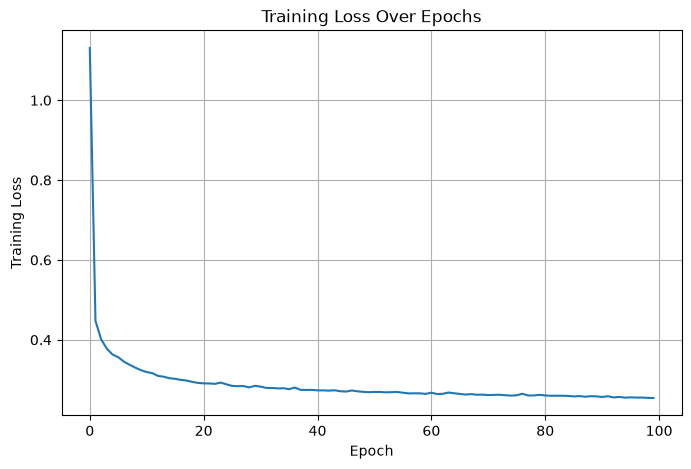

In [12]:
# evaluate model on test data
plt.figure(figsize=(8, 5))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

In [13]:
# evaluate the model on the test set
model.eval()

with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)

y_pred_mlp = y_pred_tensor.numpy().flatten()

mse_mlp = mean_squared_error(y_test, y_pred_mlp)
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print("MLP Regression Results")
print("MSE:", mse_mlp)
print("MAE:", mae_mlp)
print("R²:", r2_mlp)

MLP Regression Results
MSE: 0.27870253468791845
MAE: 0.3471141430735934
R²: 0.7873163727387993


Mô hình MLP đạt R² = 0.7873 trên tập kiểm tra, cho thấy mô hình giải thích được khoảng 78.73% sự biến thiên của giá nhà. Giá trị MAE = 0.3471 cho thấy sai số dự đoán trung bình ở mức chấp nhận được đối với bài toán hồi quy giá nhà. Nhìn chung, mô hình hoạt động khá tốt và đã học được xu hướng chính giữa các đặc trưng đầu vào và giá nhà. Tuy nhiên, dựa trên biểu đồ Actual vs Predicted, mô hình vẫn còn dự đoán thấp ở một số căn nhà có giá trị cao, vì vậy vẫn có thể cải thiện thêm bằng cách tinh chỉnh kiến trúc mạng, learning rate hoặc số epoch.

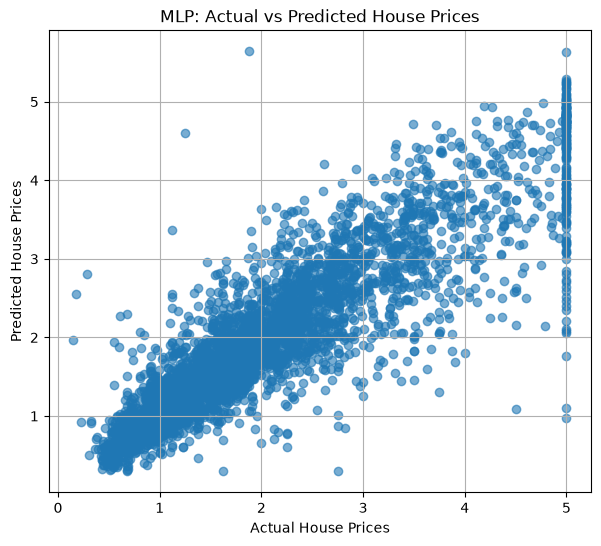

In [ ]:
# Visualize the results between actual and predicted house prices
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_mlp, alpha=0.6)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("MLP: Actual vs Predicted House Prices")
plt.grid(True)
plt.show()

In [15]:
# Compare the performance of different regression models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []

for name, reg_model in models.items():
    reg_model.fit(X_train_scaled, y_train)

    y_pred = reg_model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MSE": mse,
        "MAE": mae,
        "R2": r2
    })

results.append({
    "Model": "MLP PyTorch",
    "MSE": mse_mlp,
    "MAE": mae_mlp,
    "R2": r2_mlp
})

results_df = pd.DataFrame(results)
results_df

,Model,MSE,MAE,R2
0,Linear Regression,0.555892,0.533200,0.575788
1,Decision Tree,0.492988,0.453172,0.623791
2,Random Forest,0.255915,0.327766,0.804706
3,MLP PyTorch,0.278703,0.347114,0.787316


In [16]:
# choose the best model based on R² score
results_df.sort_values(by="R2", ascending=False)

,Model,MSE,MAE,R2
2,Random Forest,0.255915,0.327766,0.804706
3,MLP PyTorch,0.278703,0.347114,0.787316
1,Decision Tree,0.492988,0.453172,0.623791
0,Linear Regression,0.555892,0.533200,0.575788


Random Forest thường cho kết quả ổn định hơn vì mô hình này kết hợp nhiều cây quyết định, giúp giảm overfitting so với một Decision Tree đơn lẻ. MLP có khả năng học quan hệ phi tuyến, nhưng hiệu quả phụ thuộc mạnh vào kiến trúc mạng, learning rate, số epoch và cách chuẩn hóa dữ liệu
